# **CV Assignment 01: Image Enhancement**

### Name: Deira Aisya Refani
### NIM: 24/532821/PA/22539
### Class: CS

# Import Libraries and Dependencies

The following libraries are used in this program to perform image processing and visualization:

**OpenCV (cv2)**  
OpenCV is used for image processing operations such as reading images, converting color spaces, and applying various image enhancement techniques.

**NumPy (np)**  
NumPy is used for numerical computations and array manipulation. Since images are represented as multidimensional arrays of pixel values, NumPy helps perform operations such as matrix calculations, filtering, and convolution.

**Matplotlib (plt)**  
Matplotlib is used to display and visualize images and results. It allows the program to show the original image and the processed image side-by-side for comparison.

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Blurred Image - Laplacian Sharpening

A blurred image occurs when edges and fine details appear unclear due to loss of high-frequency components. To restore the sharpness of the image, **Laplacian sharpening** can be applied.

The Laplacian operator is a **second-order derivative filter** that highlights regions with rapid intensity changes, such as edges. By adding the Laplacian result back to the original image, the high-frequency details are enhanced, making the image appear sharper.

The sharpening process is defined as:

$$
I_{sharp} = I + \alpha \nabla^2 I
$$

where:

* $I$ = original image  
* $\nabla^2 I$ = Laplacian of the image  
* $\alpha$ = sharpening factor controlling the strength of enhancement

This method enhances edges and improves the overall clarity of the blurred image.

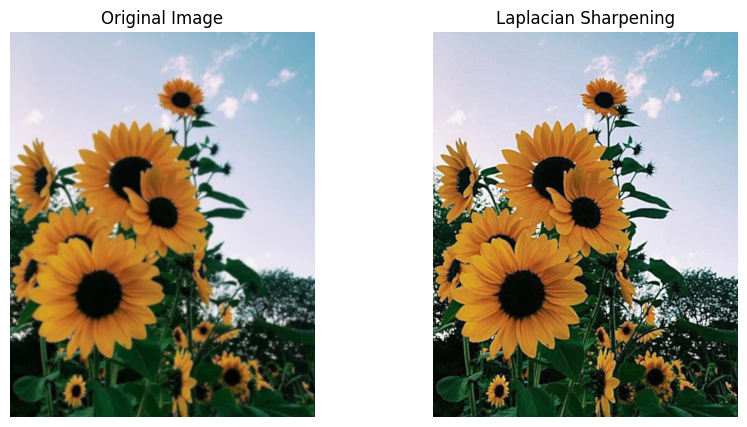

In [11]:
# Load blurred image
image = cv2.imread("./images/blurred_image.png")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB).astype(np.float32)

# Laplacian kernel
kernel = np.array([[0, -1, 0],
                   [-1, 4, -1],
                   [0, -1, 0]])

pad = 1

# Padding
padded = np.pad(image_rgb, ((pad,pad),(pad,pad),(0,0)), mode='edge')

laplacian = np.zeros_like(image_rgb)

# Convolution
for c in range(3):
    for i in range(image_rgb.shape[0]):
        for j in range(image_rgb.shape[1]):
            window = padded[i:i+3, j:j+3, c]
            laplacian[i,j,c] = np.sum(window * kernel)

# Sharpening
alpha = 6
sharpen = image_rgb + alpha * laplacian

sharpen = np.clip(sharpen,0,255).astype(np.uint8)

# Display
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image_rgb.astype(np.uint8))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(sharpen)
plt.title("Laplacian Sharpening")
plt.axis("off")

plt.show()

# Noisy Image - Median Filtering

Median filtering is used to remove noise from an image, especially **salt-and-pepper noise**. The method works by replacing each pixel value with the **median value of its neighboring pixels** within a small window (kernel).

The filtering operation can be expressed as:

$$
g(x,y) = \text{median} \{ f(i,j) \mid (i,j) \in S_{xy} \}
$$

where:

* $f(i,j)$ = original pixel intensity
* $S_{xy}$ = neighborhood window (e.g., $3 \times 3$)
* $g(x,y)$ = filtered pixel value

This process removes extreme noise values while preserving important image details such as edges.

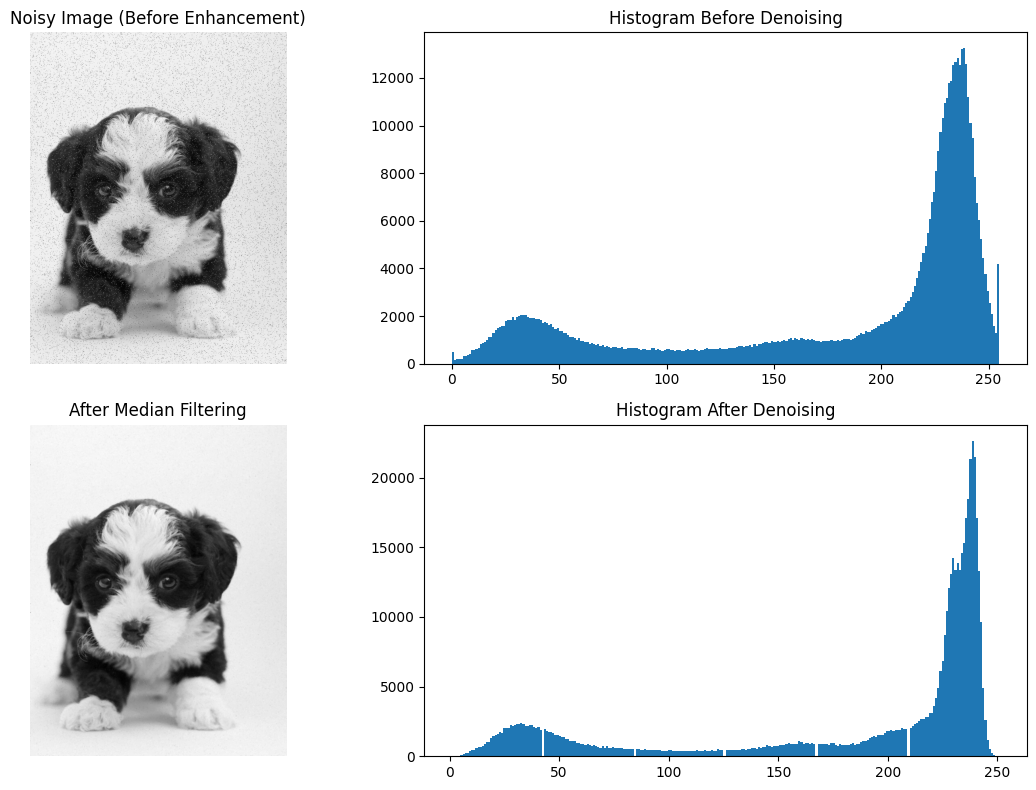

In [12]:
# Load noisy image
image = cv2.imread("./images/noisy_image.jpg")

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Median Filter
kernel_size = 3
pad = kernel_size // 2
padded = np.pad(gray, pad, mode='edge')
denoised = np.zeros_like(gray)
for i in range(gray.shape[0]):
    for j in range(gray.shape[1]):
        window = padded[i:i+kernel_size, j:j+kernel_size]
        median_value = np.median(window)
        denoised[i, j] = median_value

# Display
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Noisy Image (Before Enhancement)")
plt.axis("off")

plt.subplot(2,2,2)
plt.hist(gray.ravel(), bins=256)
plt.title("Histogram Before Denoising")

plt.subplot(2,2,3)
plt.imshow(denoised, cmap='gray')
plt.title("After Median Filtering")
plt.axis("off")

plt.subplot(2,2,4)
plt.hist(denoised.ravel(), bins=256)
plt.title("Histogram After Denoising")

plt.tight_layout()
plt.show()

# Too Dark Image - Histogram Equalization

Histogram Equalization is used to improve the contrast of a **dark image** by redistributing pixel intensities across the full range ([0,255]). Dark images usually have most intensity values concentrated at low levels.

First, the **histogram** of the image is computed. Then it is normalized to obtain the **probability density function (PDF)**:

$$
p(r_k) = \frac{n_k}{N}
$$

Next, the **cumulative distribution function (CDF)** is calculated:

$$
CDF(r_k) = \sum_{j=0}^{k} p(r_j)
$$

Finally, the new pixel value is obtained using:

$$
s_k = (L-1)\,CDF(r_k)
$$

where $L$ is the number of gray levels (256). This process spreads intensity values more evenly and enhances the image contrast.

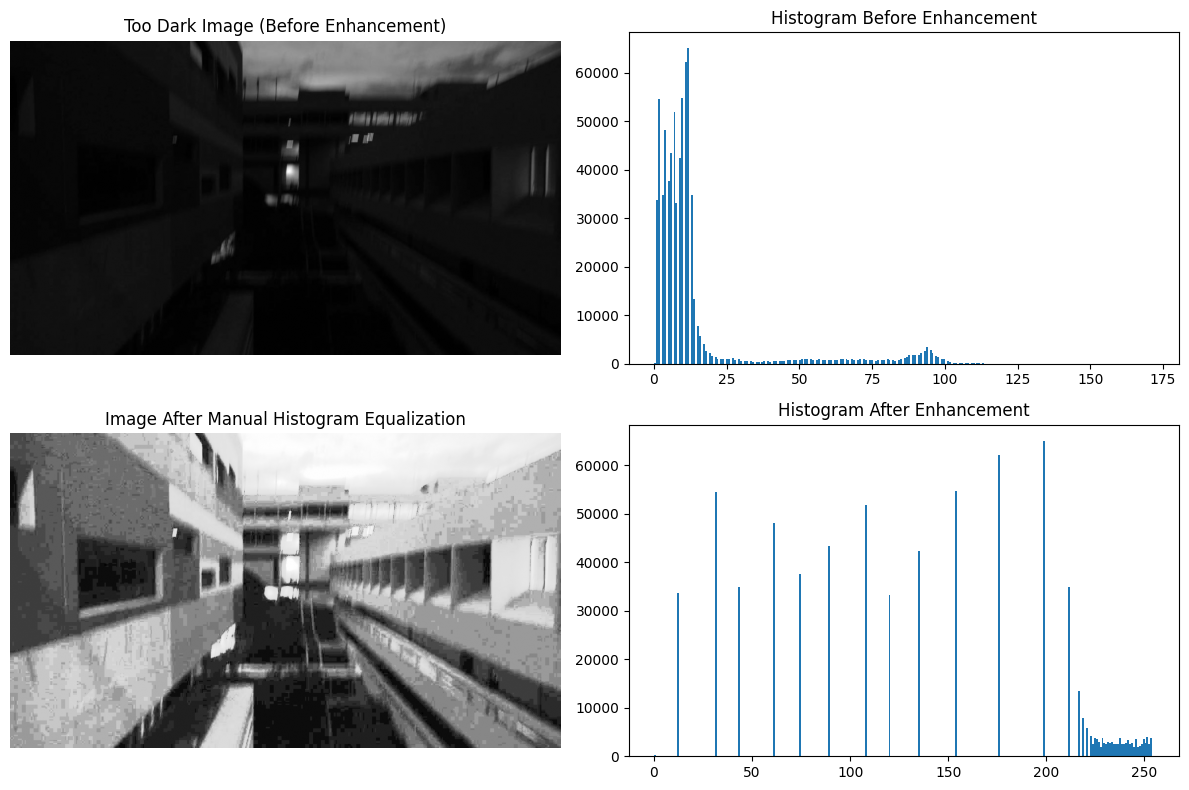

In [13]:
# Load dark image
image = cv2.imread("./images/too_dark_image.jpg")

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Histogram equalization 
hist = np.zeros(256)
for pixel in gray.flatten():
    hist[pixel] += 1
num_pixels = gray.shape[0] * gray.shape[1]
pdf = hist / num_pixels
cdf = np.cumsum(pdf)
L = 256
mapping = np.floor((L - 1) * cdf).astype(np.uint8)
equalized = mapping[gray]

# Display
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Too Dark Image (Before Enhancement)")
plt.axis("off")

plt.subplot(2,2,2)
plt.hist(gray.ravel(), bins=256)
plt.title("Histogram Before Enhancement")

plt.subplot(2,2,3)
plt.imshow(equalized, cmap='gray')
plt.title("Image After Manual Histogram Equalization")
plt.axis("off")

plt.subplot(2,2,4)
plt.hist(equalized.ravel(), bins=256)
plt.title("Histogram After Enhancement")

plt.tight_layout()
plt.show()

# Too Bright Image - Gamma Correction

Gamma correction is used to adjust the **brightness of an image** using a nonlinear transformation. For overly bright images, a **gamma value greater than 1 ($\gamma > 1$)** is used to darken the image.

The transformation is defined as:

$$
I_{out} = 255 \left(\frac{I_{in}}{255}\right)^{\gamma}
$$

where:

* $I_{in}$ = input pixel intensity
* $I_{out}$ = output pixel intensity
* $\gamma$ = gamma value controlling brightness

When $\gamma > 1$, high intensity values are compressed, reducing excessive brightness and improving visual balance in the image.

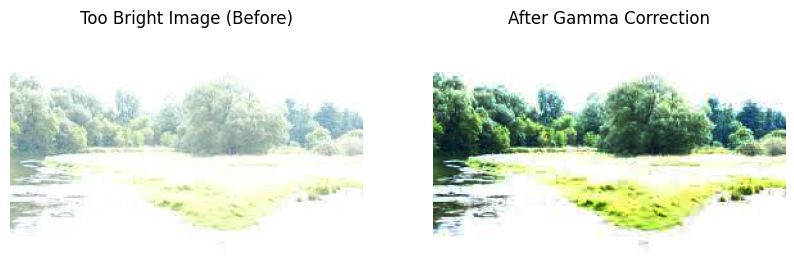

In [14]:
# Load bright image
image = cv2.imread("./images/too_bright_image.jpeg")

# Convert BGR to RGB for display
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Gamma correction
gamma = 4.0
invGamma = 1.0 / gamma

table = np.array([(i / 255.0) ** gamma * 255
                  for i in np.arange(0, 256)]).astype("uint8")

corrected = cv2.LUT(image_rgb, table)

# Display
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image_rgb)
plt.title("Too Bright Image (Before)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(corrected)
plt.title("After Gamma Correction")
plt.axis("off")

plt.show()

# Low Visibility of Bright Details - Negative Image

Image negative is used to **enhance bright details in images with dark backgrounds** by reversing the pixel intensity values.

The transformation is defined as:

$$
s = (L - 1) - r
$$

where:

* $r$ = input pixel intensity
* $s$ = output pixel intensity
* $L$ = maximum gray level value (usually **256** for 8-bit images)

This transformation **inverts the intensity levels** of the image:

* dark pixels become bright
* bright pixels become dark

As a result, details that were difficult to see in the original image—especially **bright objects on dark backgrounds**—can become more visible and easier to analyze.

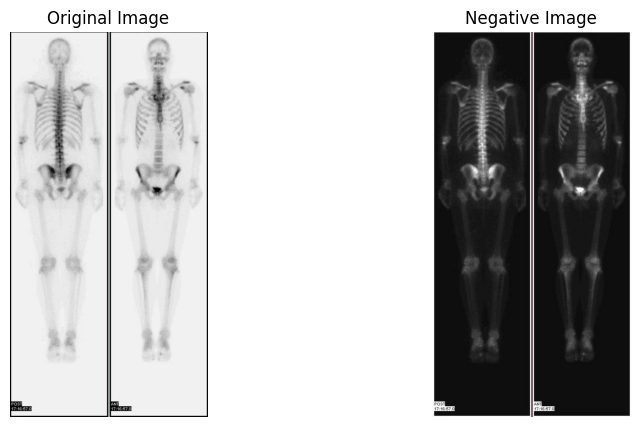

In [15]:
# Load image
image = cv2.imread("./images/low_visibility_bright_detail.jpg")

# Convert to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Image Negative
negative = 255 - image_rgb

# Display
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(negative)
plt.title("Negative Image")
plt.axis("off")

plt.show()

# Low-Contrast Image - Piecewise-Linear Transformation (Contrast Streching)

Piecewise-linear transformation is used to **enhance the contrast of an image** by stretching specific ranges of intensity values. This method increases the difference between dark and bright regions while maintaining control over how the intensities are mapped.

The transformation divides the intensity range into **three segments** and applies different linear mappings to each segment.

The transformation is defined as:

$$
s =
\begin{cases}
\frac{s_1}{r_1}r & r < r_1 \\
\frac{s_2 - s_1}{r_2 - r_1}(r - r_1) + s_1 & r_1 \le r \le r_2 \\
\frac{255 - s_2}{255 - r_2}(r - r_2) + s_2 & r > r_2
\end{cases}
$$

where:

* $r$ = input pixel intensity
* $s$ = output pixel intensity
* $r_1, r_2$ = input intensity breakpoints
* $s_1, s_2$ = output intensity values controlling the contrast stretch

By stretching the **mid-intensity range**, the contrast of the image is improved, making details more visible while preventing excessive brightness or darkness.

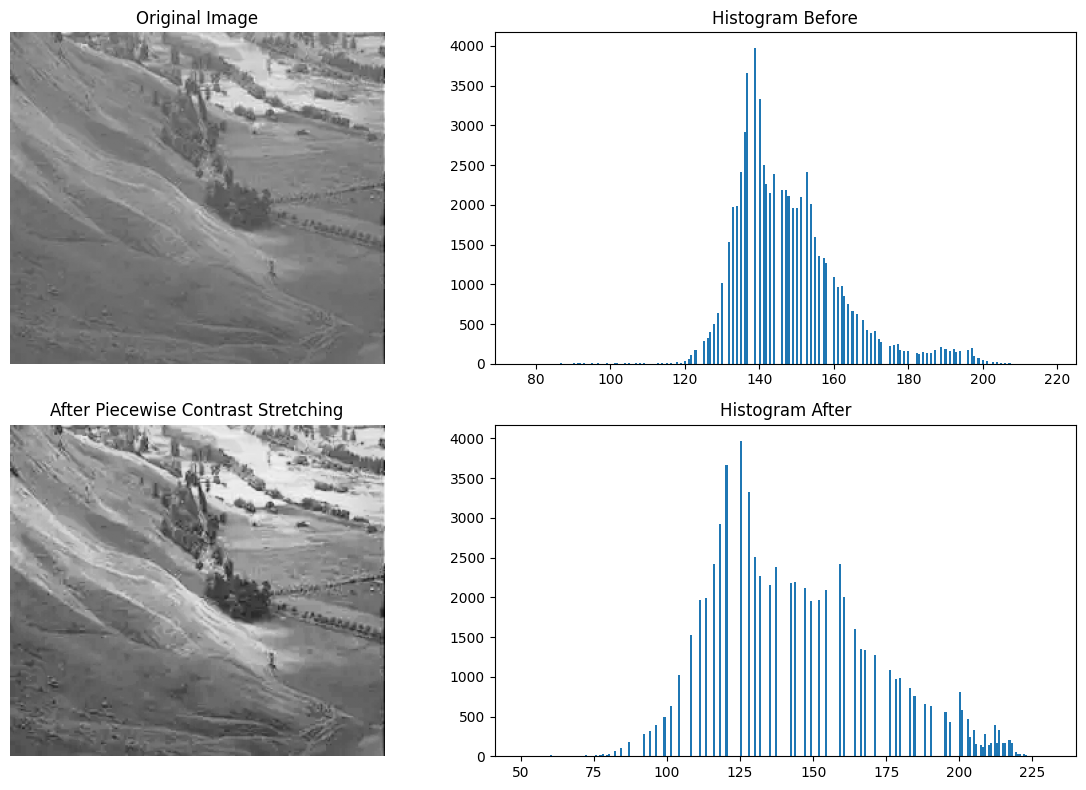

In [ ]:
# Import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
image = cv2.imread("./images/low_contrast_image.jpg")

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Define piecewise points
r1, s1 = 120, 80 
r2, s2 = 170, 200

# Create output image
piecewise = np.zeros_like(gray)

# Apply piecewise transformation
for i in range(gray.shape[0]):
    for j in range(gray.shape[1]):
        r = gray[i, j]

        if r < r1:
            piecewise[i, j] = (s1 / r1) * r
        elif r1 <= r <= r2:
            piecewise[i, j] = ((s2 - s1) / (r2 - r1)) * (r - r1) + s1
        else:
            piecewise[i, j] = ((255 - s2) / (255 - r2)) * (r - r2) + s2

# Convert to uint8
piecewise = piecewise.astype(np.uint8)

# Display
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(2,2,2)
plt.hist(gray.ravel(), bins=256)
plt.title("Histogram Before")

plt.subplot(2,2,3)
plt.imshow(piecewise, cmap='gray')
plt.title("After Piecewise Contrast Stretching")
plt.axis("off")

plt.subplot(2,2,4)
plt.hist(piecewise.ravel(), bins=256)
plt.title("Histogram After")

plt.tight_layout()
plt.show()

# Too Sharp Image - Gaussian Filtering

Gaussian filtering is used to **smooth an image and reduce excessive sharpness** by suppressing high-frequency components such as strong edges and fine noise. When an image is overly sharp, edges may appear harsh or unnatural. Applying a Gaussian filter softens these edges and produces a more natural-looking image.

The method works by applying a **Gaussian kernel** that performs weighted averaging of neighboring pixels. Pixels closer to the center receive higher weights, while those farther away contribute less to the result.

The Gaussian function is defined as:

$$
G(x,y) = \frac{1}{2\pi\sigma^2} e^{-\frac{x^2+y^2}{2\sigma^2}}
$$

where:

* $x, y$ = spatial coordinates relative to the center of the kernel  
* $\sigma$ = standard deviation controlling the amount of smoothing  
* $G(x,y)$ = Gaussian weight applied to neighboring pixels  

In practice, the Gaussian kernel is convolved with the image:

$$
I'(x,y) = \sum_{i=-k}^{k} \sum_{j=-k}^{k} I(x+i, y+j) \cdot G(i,j)
$$

where:

* $I(x,y)$ = original pixel intensity  
* $I'(x,y)$ = smoothed pixel intensity  
* $G(i,j)$ = Gaussian kernel value  

By applying this weighted smoothing, **sharp edges are softened and noise is reduced**, resulting in a smoother image with less aggressive edge transitions.

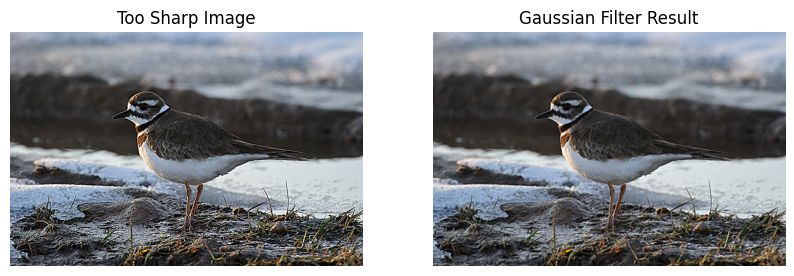

In [17]:
# Load too sharp image
image = cv2.imread("./images/too_sharp_image.jpg")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB).astype(np.float32)

# Gaussian Kernel (5x5)
kernel = (1/273) * np.array([
    [1, 4, 7, 4, 1],
    [4,16,26,16,4],
    [7,26,41,26,7],
    [4,16,26,16,4],
    [1, 4, 7, 4, 1]
])

pad = 2

# Padding
padded = np.pad(image_rgb, ((pad,pad),(pad,pad),(0,0)), mode='edge')

gaussian = np.zeros_like(image_rgb)

# Convolution
for c in range(3):
    for i in range(image_rgb.shape[0]):
        for j in range(image_rgb.shape[1]):
            window = padded[i:i+5, j:j+5, c]
            gaussian[i,j,c] = np.sum(window * kernel)

gaussian = np.clip(gaussian,0,255).astype(np.uint8)

# Display
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image_rgb.astype(np.uint8))
plt.title("Too Sharp Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(gaussian)
plt.title("Gaussian Filter Result")
plt.axis("off")

plt.show()